In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Explorative Datenanalyse mit gemergten Daten
In diesem Notebook werden die gemergten Daten analysiert, um Einblicke zu gewinnen und mögliche Muster zu erkennen.

In [2]:
merged_df = pd.read_csv('data/merged_df.csv')

### 1. Verteilungen der Variablen

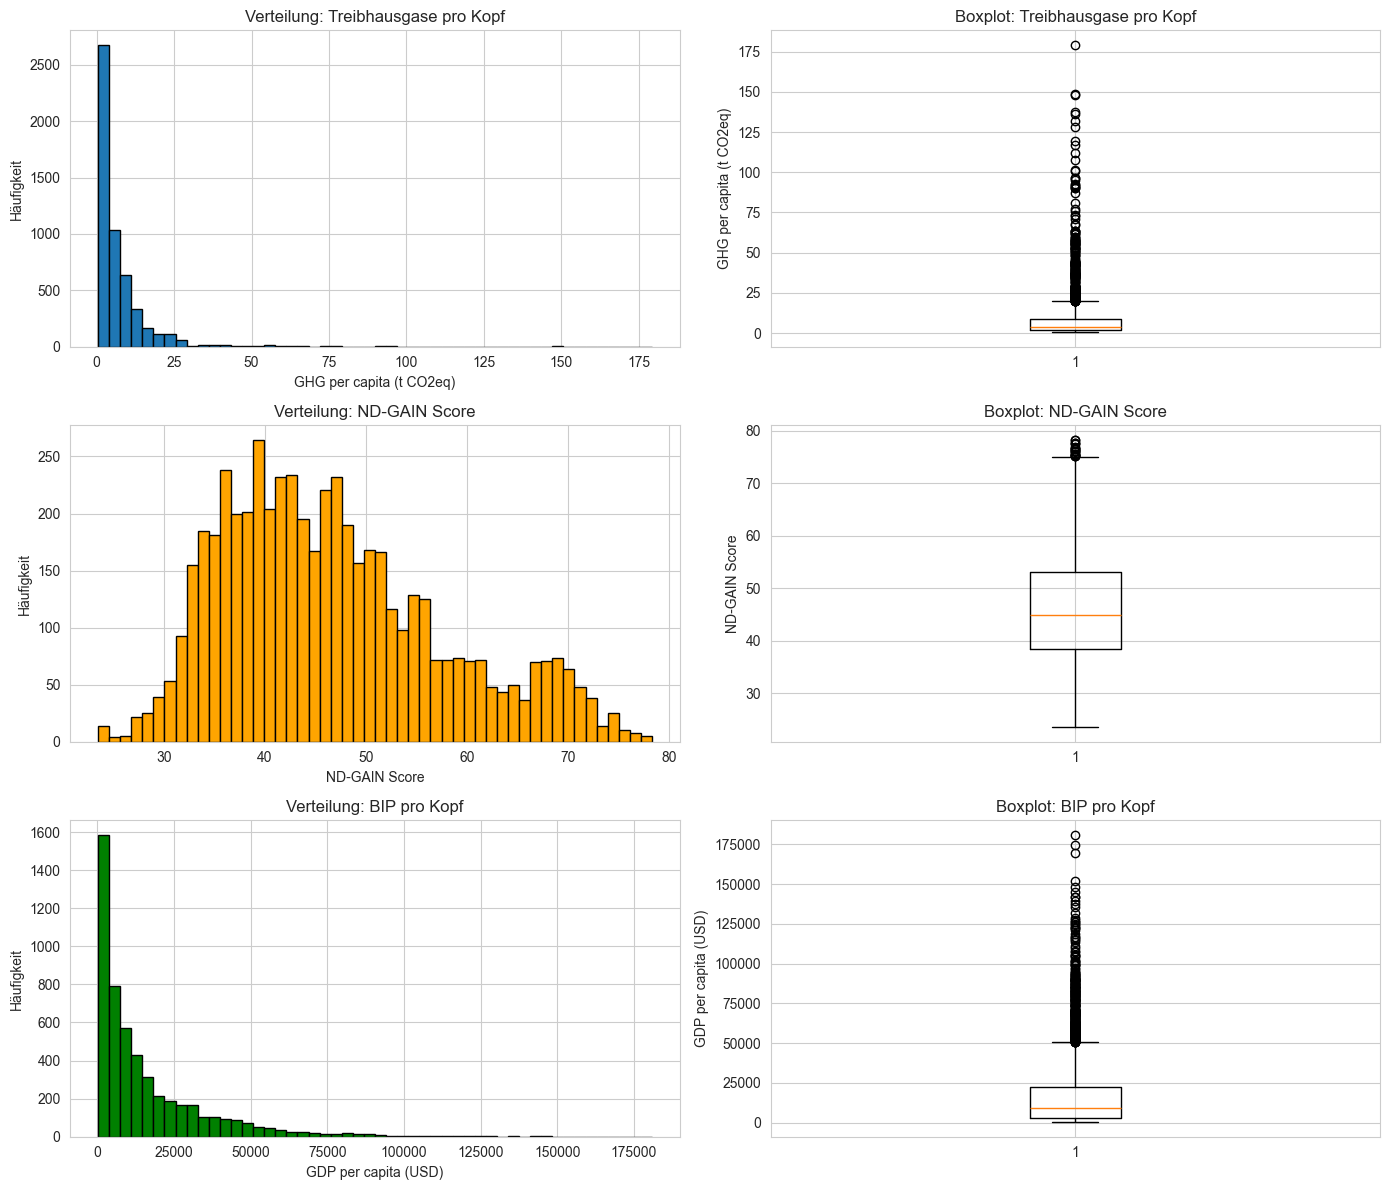

In [3]:
# Histogramme und Boxplots für die vier Hauptvariablen
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

# GHG per capita
axes[0, 0].hist(merged_df['GHG_per_capita'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_title('Verteilung: Treibhausgase pro Kopf')
axes[0, 0].set_xlabel('GHG per capita (t CO2eq)')
axes[0, 0].set_ylabel('Häufigkeit')

axes[0, 1].boxplot(merged_df['GHG_per_capita'].dropna(), vert=True)
axes[0, 1].set_title('Boxplot: Treibhausgase pro Kopf')
axes[0, 1].set_ylabel('GHG per capita (t CO2eq)')

# ND-GAIN
axes[1, 0].hist(merged_df['ND_GAIN'].dropna(), bins=50, edgecolor='black', color='orange')
axes[1, 0].set_title('Verteilung: ND-GAIN Score')
axes[1, 0].set_xlabel('ND-GAIN Score')
axes[1, 0].set_ylabel('Häufigkeit')

axes[1, 1].boxplot(merged_df['ND_GAIN'].dropna(), vert=True)
axes[1, 1].set_title('Boxplot: ND-GAIN Score')
axes[1, 1].set_ylabel('ND-GAIN Score')

# Vulnerability
axes[2, 0].hist(merged_df['Vulnerability'].dropna(), bins=50, edgecolor='black', color='red')
axes[2, 0].set_title('Verteilung: Vulnerability Score')
axes[2, 0].set_xlabel('Vulnerability Score')
axes[2, 0].set_ylabel('Häufigkeit')

axes[2, 1].boxplot(merged_df['Vulnerability'].dropna(), vert=True)
axes[2, 1].set_title('Boxplot: Vulnerability Score')
axes[2, 1].set_ylabel('Vulnerability Score')

# GDP per capita
axes[3, 0].hist(merged_df['GDP_per_capita'].dropna(), bins=50, edgecolor='black', color='green')
axes[3, 0].set_title('Verteilung: BIP pro Kopf')
axes[3, 0].set_xlabel('GDP per capita (USD)')
axes[3, 0].set_ylabel('Häufigkeit')

axes[3, 1].boxplot(merged_df['GDP_per_capita'].dropna(), vert=True)
axes[3, 1].set_title('Boxplot: BIP pro Kopf')
axes[3, 1].set_ylabel('GDP per capita (USD)')

plt.tight_layout()
plt.show()

### 2. Zeitliche Entwicklung

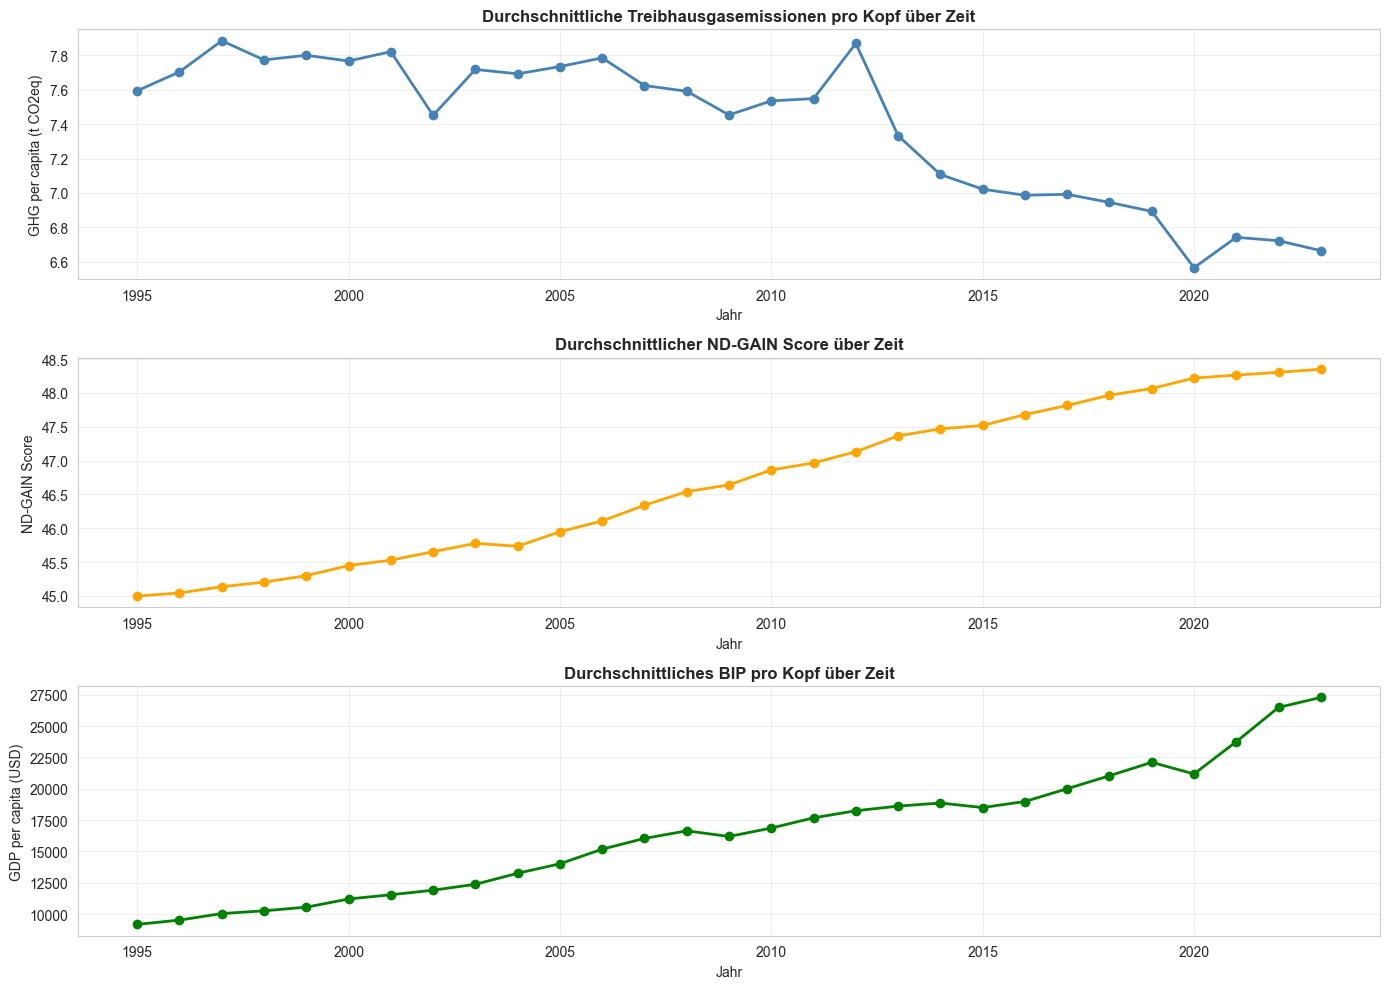

In [4]:
# Durchschnittliche Entwicklung über die Zeit
yearly_avg = merged_df.groupby('Year')[['GHG_per_capita', 'ND_GAIN', 'Vulnerability', 'GDP_per_capita']].mean()

fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# GHG Entwicklung
axes[0].plot(yearly_avg.index, yearly_avg['GHG_per_capita'], marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Durchschnittliche Treibhausgasemissionen pro Kopf über Zeit', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jahr')
axes[0].set_ylabel('GHG per capita (t CO2eq)')
axes[0].grid(True, alpha=0.3)

# ND-GAIN Entwicklung
axes[1].plot(yearly_avg.index, yearly_avg['ND_GAIN'], marker='o', linewidth=2, color='orange')
axes[1].set_title('Durchschnittlicher ND-GAIN Score über Zeit', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jahr')
axes[1].set_ylabel('ND-GAIN Score')
axes[1].grid(True, alpha=0.3)

# Vulnerability Entwicklung
axes[2].plot(yearly_avg.index, yearly_avg['Vulnerability'], marker='o', linewidth=2, color='red')
axes[2].set_title('Durchschnittlicher Vulnerability Score über Zeit', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Jahr')
axes[2].set_ylabel('Vulnerability Score')
axes[2].grid(True, alpha=0.3)

# GDP Entwicklung
axes[3].plot(yearly_avg.index, yearly_avg['GDP_per_capita'], marker='o', linewidth=2, color='green')
axes[3].set_title('Durchschnittliches BIP pro Kopf über Zeit', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Jahr')
axes[3].set_ylabel('GDP per capita (USD)')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Top 10 Länder höchsten/tiefsten durchschnittlichen Werten (über alle Jahre Gruppiert pro Land)
country_avg = merged_df.groupby(['ISO3', 'Country'])[['GHG_per_capita', 'ND_GAIN', 'Vulnerability', 'GDP_per_capita']].mean()

print("10 Länder mit höchsten GHG-Ausstoss:")
top_ghg = country_avg.nlargest(10, 'GHG_per_capita')[['GHG_per_capita']]
print(top_ghg)

print("\n10 Länder mit niedrigstem GHG-Ausstoss:")
bottom_ghg = country_avg.nsmallest(10, 'GHG_per_capita')[['GHG_per_capita']]
print(bottom_ghg)

10 Länder mit höchsten GHG-Ausstoss:
                           GHG_per_capita
ISO3 Country                             
PLW  Palau                      94.373213
QAT  Qatar                      67.779674
BHR  Bahrain                    45.525954
KWT  Kuwait                     41.847963
ARE  United Arab Emirates       31.171155
TTO  Trinidad and Tobago        26.978945
AUS  Australia                  26.477225
BRN  Brunei                     25.817575
OMN  Oman                       24.184531
CAN  Canada                     22.088431

10 Länder mit niedrigstem GHG-Ausstoss:
                                       GHG_per_capita
ISO3 Country                                         
COD  Democratic Republic of the Congo        0.520347
BDI  Burundi                                 0.530034
RWA  Rwanda                                  0.590120
MOZ  Mozambique                              0.750511
MWI  Malawi                                  0.754370
KIR  Kiribati                           

In [6]:
print("10 Länder mit höchsten ND-GAIN Score (besser vorbereitet):")
top_gain = country_avg.nlargest(10, 'ND_GAIN')[['ND_GAIN']]
print(top_gain)

print("\n10 Länder mit niedrigstem ND-GAIN Score (höchstes Risiko):")
bottom_gain = country_avg.nsmallest(10, 'ND_GAIN')[['ND_GAIN']]
print(bottom_gain)

10 Länder mit höchsten ND-GAIN Score (besser vorbereitet):
                       ND_GAIN
ISO3 Country                  
NOR  Norway          74.539021
FIN  Finland         73.407065
NZL  New Zealand     71.487862
DNK  Denmark         71.109743
CHE  Switzerland     70.496303
SWE  Sweden          70.393536
GBR  United Kingdom  69.745953
DEU  Germany         68.818161
CAN  Canada          68.508054
ISL  Iceland         68.436189

10 Länder mit niedrigstem ND-GAIN Score (höchstes Risiko):
                                         ND_GAIN
ISO3 Country                                    
TCD  Chad                              25.467059
CAF  Central African Republic          29.002565
GNB  Guinea-Bissau                     29.796960
NER  Niger                             30.952769
SDN  Sudan and South Sudan             31.290499
COD  Democratic Republic of the Congo  31.567455
SLE  Sierra Leone                      32.423056
ERI  Eritrea                           32.506553
AFG  Afghanistan   

In [79]:
print("\n10 Länder mit höchstem Vulnerability Score (höchste Vulnerabilität):")
top_vul = country_avg.nlargest(10, 'Vulnerability')[['Vulnerability']]
print(top_vul)

print("\n10 Länder mit niedrigstem Vulnerability Score (niedrigste Vulnerabilität):")
bottom_vul = country_avg.nsmallest(10, 'Vulnerability')[['Vulnerability']]
print(bottom_vul)


10 Länder mit höchstem Vulnerability Score (höchste Vulnerabilität):
                            Vulnerability
ISO3 Country                             
TCD  Chad                        0.646341
SLB  Solomon Islands             0.640106
NER  Niger                       0.639739
GNB  Guinea-Bissau               0.638606
SOM  Somalia                     0.626671
SDN  Sudan and South Sudan       0.612227
TON  Tonga                       0.608967
MLI  Mali                        0.603209
ERI  Eritrea                     0.602495
SLE  Sierra Leone                0.601131

10 Länder mit niedrigstem Vulnerability Score (niedrigste Vulnerabilität):
                     Vulnerability
ISO3 Country                      
NOR  Norway               0.257795
CZE  Czechia              0.261011
GBR  United Kingdom       0.279789
CHE  Switzerland          0.280748
FIN  Finland              0.284520
CAN  Canada               0.284653
AUT  Austria              0.301886
DEU  Germany              0.304972


In [7]:
print("\n10 Länder mit höchstem BIP pro Kopf:")
top_gdp = country_avg.nlargest(10, 'GDP_per_capita')[['GDP_per_capita']]
print(top_gdp)

print("\n10 Länder mit niedrigstem BIP pro Kopf:")
bottom_gdp = country_avg.nsmallest(10, 'GDP_per_capita')[['GDP_per_capita']]
print(bottom_gdp)


10 Länder mit höchstem BIP pro Kopf:
                           GDP_per_capita
ISO3 Country                             
QAT  Qatar                  112115.430308
LUX  Luxembourg              87026.465127
ARE  United Arab Emirates    84864.383064
BRN  Brunei                  75583.123149
SGP  Singapore               74263.369002
KWT  Kuwait                  64195.846369
NOR  Norway                  56365.618514
IRL  Ireland                 56077.797987
CHE  Switzerland             54363.937274
SAU  Saudi Arabia            53633.503025

10 Länder mit niedrigstem BIP pro Kopf:
                                       GDP_per_capita
ISO3 Country                                         
BDI  Burundi                               649.368518
COD  Democratic Republic of the Congo      731.386123
CAF  Central African Republic              821.769054
SOM  Somalia                               908.443745
MOZ  Mozambique                            941.973422
NER  Niger                             

### 3. Korrelationsanalyse

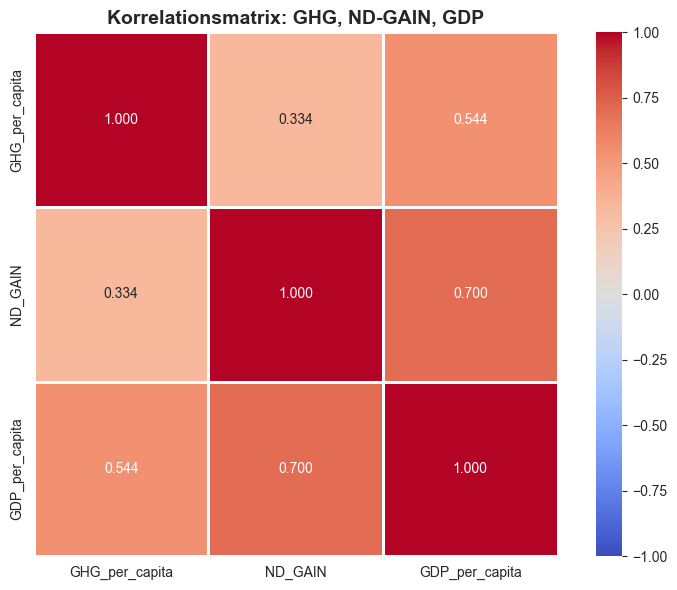

In [8]:
# Korrelationsmatrix
correlation_matrix = merged_df[['GHG_per_capita', 'ND_GAIN', 'Vulnerability', 'GDP_per_capita']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.3f', vmin=-1, vmax=1)
plt.title('Korrelationsmatrix: GHG, ND-GAIN, Vulnerability, GDP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

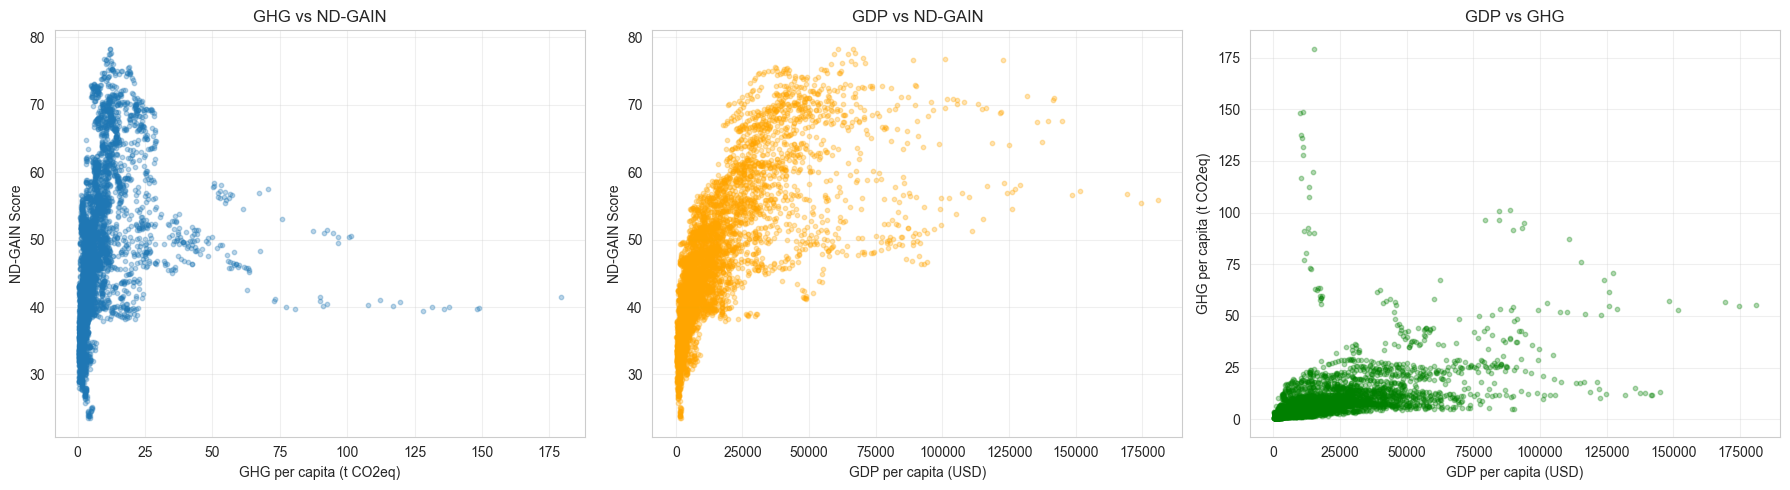

In [9]:
# Scatter Plots für paarweise Beziehungen
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# GHG vs ND-GAIN
axes[0, 0].scatter(merged_df['GHG_per_capita'], merged_df['ND_GAIN'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('GHG per capita (t CO2eq)')
axes[0, 0].set_ylabel('ND-GAIN Score')
axes[0, 0].set_title('GHG vs ND-GAIN')
axes[0, 0].grid(True, alpha=0.3)

# GHG vs Vulnerability
axes[0, 1].scatter(merged_df['GHG_per_capita'], merged_df['Vulnerability'], alpha=0.3, s=10, color='red')
axes[0, 1].set_xlabel('GHG per capita (t CO2eq)')
axes[0, 1].set_ylabel('Vulnerability Score')
axes[0, 1].set_title('GHG vs Vulnerability')
axes[0, 1].grid(True, alpha=0.3)

# GDP vs ND-GAIN
axes[0, 2].scatter(merged_df['GDP_per_capita'], merged_df['ND_GAIN'], alpha=0.3, s=10, color='orange')
axes[0, 2].set_xlabel('GDP per capita (USD)')
axes[0, 2].set_ylabel('ND-GAIN Score')
axes[0, 2].set_title('GDP vs ND-GAIN')
axes[0, 2].grid(True, alpha=0.3)

# GDP vs Vulnerability
axes[1, 0].scatter(merged_df['GDP_per_capita'], merged_df['Vulnerability'], alpha=0.3, s=10, color='purple')
axes[1, 0].set_xlabel('GDP per capita (USD)')
axes[1, 0].set_ylabel('Vulnerability Score')
axes[1, 0].set_title('GDP vs Vulnerability')
axes[1, 0].grid(True, alpha=0.3)

# GDP vs GHG
axes[1, 1].scatter(merged_df['GDP_per_capita'], merged_df['GHG_per_capita'], alpha=0.3, s=10, color='green')
axes[1, 1].set_xlabel('GDP per capita (USD)')
axes[1, 1].set_ylabel('GHG per capita (t CO2eq)')
axes[1, 1].set_title('GDP vs GHG')
axes[1, 1].grid(True, alpha=0.3)

# ND-GAIN vs Vulnerability
axes[1, 2].scatter(merged_df['ND_GAIN'], merged_df['Vulnerability'], alpha=0.3, s=10, color='brown')
axes[1, 2].set_xlabel('ND-GAIN Score')
axes[1, 2].set_ylabel('Vulnerability Score')
axes[1, 2].set_title('ND-GAIN vs Vulnerability')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Länderspezifische Analysen

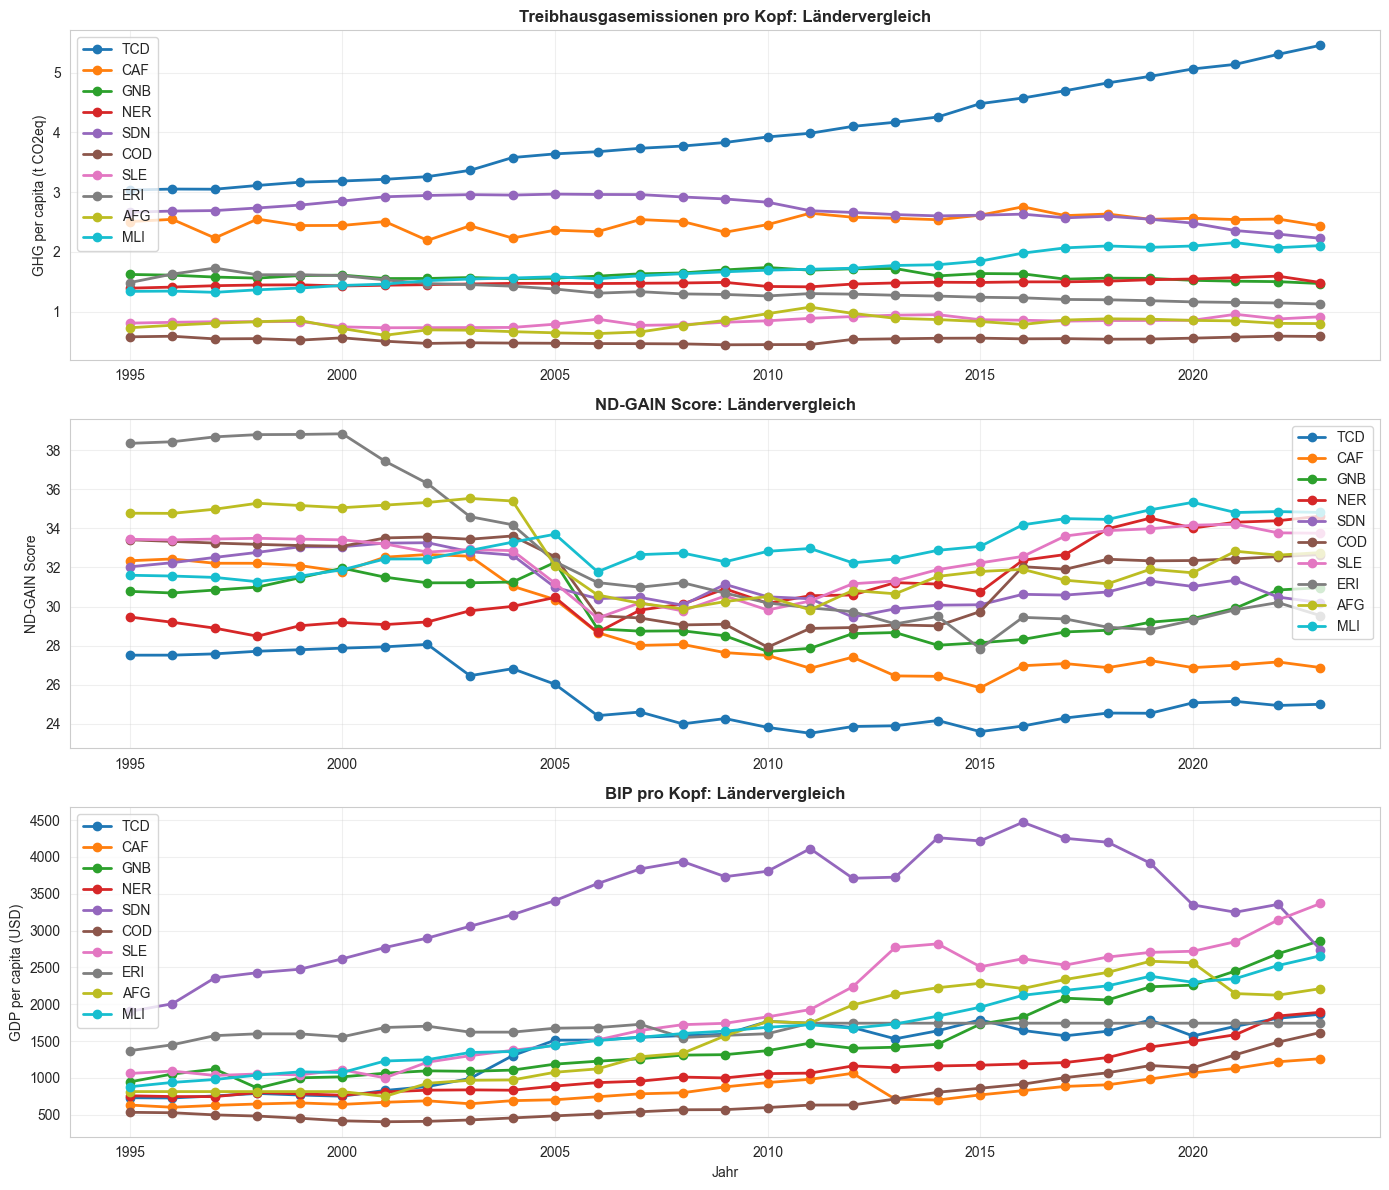

In [10]:
# Vergleich ausgewählter Länder
# Top 10 tiefster ND-Gain
countries_of_interest = ['TCD', 'CAF', 'GNB', 'NER', 'SDN', 'COD', 'SLE', 'ERI', 'AFG', 'MLI']
# Top 10 höchster ND-Gain
# countries_of_interest = ['NOR', 'FIN', 'NZL', 'DNK', 'CHE', 'SWE', 'GBR', 'DEU', 'CAN', 'ISL']
# Top 10 tiefster GHG-Ausstoss
# countries_of_interest = ['COD', 'BDI', 'RWA', 'MOZ', 'MWI', 'KIR', 'COM', 'AFG', 'LBR', 'SLE']
# Top 10 höchster GHG-Ausstoss
# countries_of_interest = ['PLW', 'QAT', 'BHR', 'KWT', 'ARE', 'TTO', 'AUS', 'BRN', 'OMN', 'CAN']
# Top 10 höchster Vulnerability
# countries_of_interest = ['TCD', 'SLB', 'NER', 'GNB', 'SOM', 'SDN', 'TON', 'MLI', 'ERI', 'SLE']
# Top 10 tiefster Vulnerability
# countries_of_interest = ['NOR', 'CZE', 'GBR', 'CHE', 'FIN', 'CAN', 'AUT', 'DEU', 'FRA', 'ESP']
# Top 10 höchster GDP
# countries_of_interest = ['QAT', 'LUX', 'ARE', 'BRN', 'SGP', 'KWT', 'NOR', 'IRL', 'CHE', 'SAU']
# Top 10 tiefster GDP
# countries_of_interest = ['BDI', 'COD', 'CAF', 'SOM', 'MOZ', 'NER', 'LBR', 'ETH', 'MWI', 'TCD']

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

for country in countries_of_interest:
    country_data = merged_df[merged_df['ISO3'] == country].sort_values('Year')
    
    if not country_data.empty:
        # GHG Entwicklung
        axes[0].plot(country_data['Year'], country_data['GHG_per_capita'], 
                    marker='o', label=country, linewidth=2)
        
        # ND-GAIN Entwicklung
        axes[1].plot(country_data['Year'], country_data['ND_GAIN'], 
                    marker='o', label=country, linewidth=2)
        
        # Vulnerability Entwicklung
        axes[2].plot(country_data['Year'], country_data['Vulnerability'], 
                    marker='o', label=country, linewidth=2)
        
        # GDP Entwicklung
        axes[3].plot(country_data['Year'], country_data['GDP_per_capita'], 
                    marker='o', label=country, linewidth=2)

axes[0].set_title('Treibhausgasemissionen pro Kopf: Ländervergleich', fontsize=12, fontweight='bold')
axes[0].set_ylabel('GHG per capita (t CO2eq)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('ND-GAIN Score: Ländervergleich', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ND-GAIN Score')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

axes[2].set_title('Vulnerability Score: Ländervergleich', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Vulnerability Score')
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

axes[3].set_title('BIP pro Kopf: Ländervergleich', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Jahr')
axes[3].set_ylabel('GDP per capita (USD)')
axes[3].legend(loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5. Klassifizierung der Länder


Niedrig GHG, Hohes Risiko: 73 Länder
['Afghanistan', 'Angola', 'Albania', 'Burundi', 'Benin', 'Burkina Faso', 'Bangladesh', 'Belize', 'Central African Republic', 'Côte d’Ivoire']

Hoch GHG, Niedriges Risiko: 73 Länder
['United Arab Emirates', 'Argentina', 'Australia', 'Austria', 'Azerbaijan', 'Belgium', 'Bulgaria', 'Bahrain', 'Bahamas', 'Bosnia and Herzegovina']

Niedrig GHG, Niedriges Risiko: 18 Länder
['Armenia', 'Antigua and Barbuda', 'Barbados', 'Bhutan', 'Cabo Verde', 'Costa Rica', 'Dominica', 'Fiji', 'Georgia', 'Grenada']

Hoch GHG, Hohes Risiko: 18 Länder
['Bolivia', 'Congo', 'Colombia', 'Ecuador', 'Gabon', 'Equatorial Guinea', 'Guyana', 'Iraq', 'Lebanon', 'Libya']


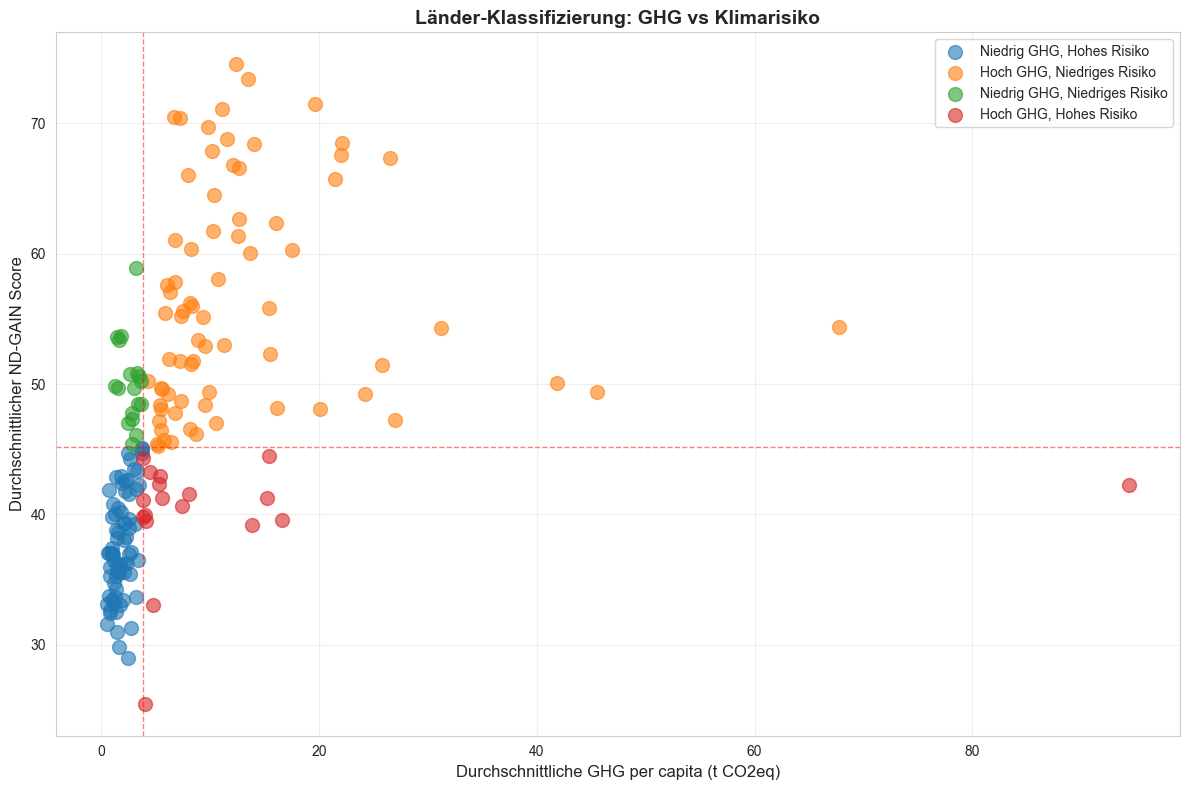

In [11]:
# Klassifizierung der Länder nach Durchschnittswerten (über alle Jahre)
# Nutzen der country_avg Variable

# Kategorisierung nach Medianen
ghg_median = country_avg['GHG_per_capita'].median()
gain_median = country_avg['ND_GAIN'].median()

# 4 Kategorien:
# 1. Hohe GHG, Hohes Risiko (niedriges ND-GAIN)
# 2. Hohe GHG, Niedriges Risiko (hohes ND-GAIN)
# 3. Niedrige GHG, Hohes Risiko (niedriges ND-GAIN)
# 4. Niedrige GHG, Niedriges Risiko (hohes ND-GAIN)

country_avg['GHG_category'] = country_avg['GHG_per_capita'].apply(lambda x: 'Hoch' if x > ghg_median else 'Niedrig')
country_avg['Risk_category'] = country_avg['ND_GAIN'].apply(lambda x: 'Niedriges Risiko' if x > gain_median else 'Hohes Risiko')

# Kombinierte Kategorie
country_avg['Combined_category'] = country_avg['GHG_category'] + ' GHG, ' + country_avg['Risk_category']

for category in country_avg['Combined_category'].unique():
    countries_in_cat = country_avg[country_avg['Combined_category'] == category]
    print(f"\n{category}: {len(countries_in_cat)} Länder")
    print(countries_in_cat.head(10).index.get_level_values('Country').tolist())
    
# Visualisierung: 2D Plot mit Quadranten
plt.figure(figsize=(12, 8))

for category in country_avg['Combined_category'].unique():
    mask = country_avg['Combined_category'] == category
    plt.scatter(country_avg[mask]['GHG_per_capita'], 
               country_avg[mask]['ND_GAIN'],
               label=category, alpha=0.6, s=100)

# Mediane als Linien
plt.axvline(x=ghg_median, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=gain_median, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel('Durchschnittliche GHG per capita (t CO2eq)', fontsize=12)
plt.ylabel('Durchschnittlicher ND-GAIN Score', fontsize=12)
plt.title('Länder-Klassifizierung: GHG vs Klimarisiko', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()